# Logistic Regression: Drug Origin Binary Classifier
## Regresión Logística: Clasificación Binaria de Origen de Medicamento

**Author / Autora:** María Regina Castillo Treviño · [github.com/ReginaPema](https://github.com/ReginaPema)

**Dataset:** `drugs.csv` — 200 patients × 5 features  
**Target (transformed):** Drug origin — Nacional (0: drugA, drugB, drugC) vs Extranjero (1: drugX, drugY)

**Objective / Objetivo:**  
EN · Reformulate the 5-class drug problem as a binary classification task by origin (domestic vs foreign). Evaluate 12 configurations combining 5 solvers (lbfgs, liblinear, saga, sag, newton-cg) with L1, L2 and ElasticNet regularization. Select the optimal model by AUC-ROC, Accuracy and Cross-Validation F1.

ES · Reformular el problema de 5 clases como clasificación binaria por origen (nacional vs extranjero). Evaluar 12 configuraciones combinando 5 solvers con regularización L1, L2 y ElasticNet. Seleccionar el modelo óptimo por AUC-ROC, Accuracy y CV F1.

**Key finding / Hallazgo clave:** Best model — lbfgs | L2 | C=10 → AUC-ROC=1.0000, Accuracy=0.9833, CV=0.9650. 17/17 nacionales correct, 42/43 extranjeros correct.

**Techniques / Técnicas:** Logistic Regression · Solver Comparison · L1/L2/ElasticNet · AUC-ROC · Binary Transformation · 12-model grid  
**Libraries / Librerías:** `pandas` · `numpy` · `sklearn` · `matplotlib`

---

# Importación de Librerías

In [2]:
# ============================================================
# Importación de librerías
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_curve, auc,
                              ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Carga y Exploración del Dataset

In [3]:
# ============================================================
# Carga del dataset
# ============================================================
df = pd.read_csv('drugs.csv')

print('=' * 55)
print("DATASET ORIGINAL")
print('=' * 55)
print(df.head(8))
print(f"\n⋆ Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\n⋆ Distribución de clases (Drug):")
for drug, count in df['Drug'].value_counts().items():
    print(f"  {drug}: {count} ({count/len(df)*100:.1f}%)")

DATASET ORIGINAL
   Age Sex      BP Cholesterol  Na_to_K   Drug
0   23   F    HIGH        HIGH   25.355  drugY
1   47   M     LOW        HIGH   13.093  drugC
2   47   M     LOW        HIGH   10.114  drugC
3   28   F  NORMAL        HIGH    7.798  drugX
4   61   F     LOW        HIGH   18.043  drugY
5   22   F  NORMAL        HIGH    8.607  drugX
6   49   F  NORMAL        HIGH   16.275  drugY
7   41   M     LOW        HIGH   11.037  drugC

⋆ Dimensiones: 200 filas x 6 columnas

⋆ Distribución de clases (Drug):
  drugY: 91 (45.5%)
  drugX: 54 (27.0%)
  drugA: 23 (11.5%)
  drugC: 16 (8.0%)
  drugB: 16 (8.0%)


# Transformación de Variable Objetivo: Nacional vs Extranjero

VARIABLE OBJETIVO TRANSFORMADA

  Medicamento    Proveedor       Clase
  ─────────────────────────────────────
  drugA     →    Nacional     →   0
  drugB     →    Nacional     →   0
  drugC     →    Nacional     →   0
  drugX     →    Extranjero   →   1
  drugY     →    Extranjero   →   1

  ⋆ Clase 0 (Nacional (A/B/C)): 55 (27.5%)
  ⋆ Clase 1 (Extranjero (X/Y)): 145 (72.5%)



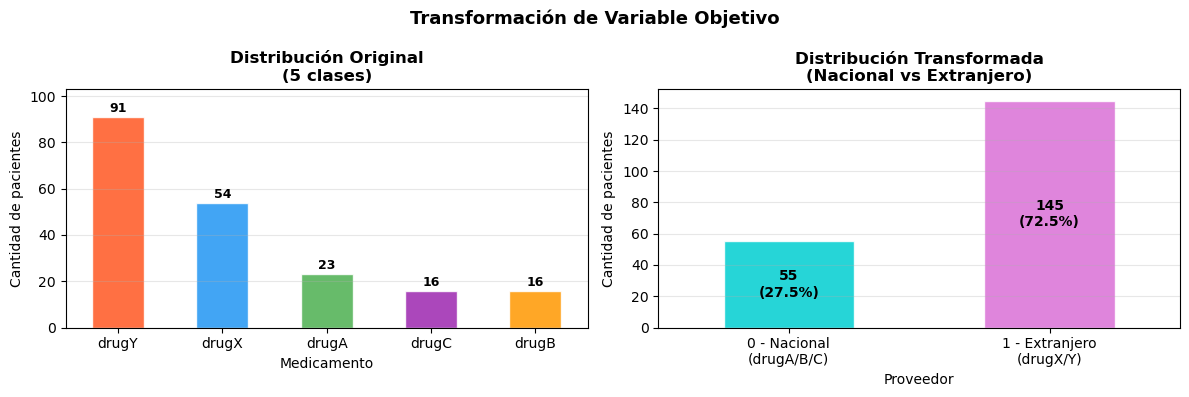

In [29]:
# ============================================================
# Transformación binaria según proveedor
# ─────────────────────────────────────────────────────────────
# Nacional → drugA, drugB, drugC → clase 0
# Extranjero → drugX, drugY → clase 1
# ============================================================

df['Proveedor'] = df['Drug'].apply(lambda x: 0 if x in ['drugA', 'drugB', 'drugC'] else 1)

etiquetas_proveedor = {0: 'Nacional (A/B/C)', 1: 'Extranjero (X/Y)'}

print('=' * 55)
print("VARIABLE OBJETIVO TRANSFORMADA")
print('=' * 55)
print("""
  Medicamento    Proveedor       Clase
  ─────────────────────────────────────
  drugA     →    Nacional     →   0
  drugB     →    Nacional     →   0
  drugC     →    Nacional     →   0
  drugX     →    Extranjero   →   1
  drugY     →    Extranjero   →   1
""")

conteo = df['Proveedor'].value_counts().sort_index()
for clase, cnt in conteo.items():
    print(f"  ⋆ Clase {clase} ({etiquetas_proveedor[clase]}): "
          f"{cnt} ({cnt/len(df)*100:.1f}%)")
print()

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Distribución original ──
conteo_original = df['Drug'].value_counts()

conteo_original.plot(
    kind='bar', ax=axes[0],
    color=['#FF5722', '#2196F3', '#4CAF50', '#9C27B0', '#FF9800'],
    edgecolor='white', alpha=0.85)

# Etiquetas sobre cada barra
for i, (droga, valor) in enumerate(conteo_original.items()):
    axes[0].text(
        i,             # posición x (índice de barra)
        valor + 0.8,   # posición y (justo encima de la barra)
        f'{valor}',    # texto: cantidad
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

axes[0].set_title('Distribución Original\n(5 clases)', fontweight='bold')
axes[0].set_xlabel('Medicamento')
axes[0].set_ylabel('Cantidad de pacientes')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylim(0, conteo_original.max() + 12)  # ← espacio para etiquetas
axes[0].grid(axis='y', alpha=0.3)

# ── Distribución transformada ──
colores_bin = ['darkturquoise', 'orchid']
conteo_plot = df['Proveedor'].value_counts().sort_index()

conteo_plot.plot(kind='bar', ax=axes[1], color=colores_bin, edgecolor='white', alpha=0.85)

# Etiquetas para cada barra
for i, v in enumerate(conteo_plot):
    axes[1].text(i, v/2,
                 f'{v}\n({v/len(df)*100:.1f}%)',
                 ha='center', va='center', fontweight='bold')

axes[1].set_title('Distribución Transformada\n(Nacional vs Extranjero)', fontweight='bold')
axes[1].set_xlabel('Proveedor')
axes[1].set_ylabel('Cantidad de pacientes')
axes[1].set_xticklabels(['0 - Nacional\n(drugA/B/C)', '1 - Extranjero\n(drugX/Y)'], rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Transformación de Variable Objetivo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rl_distribucion_clases.png', dpi=150)
plt.show()

# Preprocesamiento y División del Dataset

In [31]:
# ============================================================
# Codificación LabelEncoder + Escalado
# ============================================================
le = preprocessing.LabelEncoder()
df_enc = df.copy()

df_enc['Sex'] = le.fit_transform(df['Sex']) # F=0, M=1
df_enc['BP'] = le.fit_transform(df['BP']) # HIGH=0, LOW=1, NORMAL=2
df_enc['Cholesterol'] = le.fit_transform(df['Cholesterol']) # HIGH=0, NORMAL=1

print('=' * 55)
print("CODIFICACIÓN LabelEncoder")
print('=' * 55)
print("""
  Variable       Mapeo
  ────────────────────────────────────────
  Sex         →  F=0, M=1
  BP          →  HIGH=0, LOW=1, NORMAL=2
  Cholesterol →  HIGH=0, NORMAL=1
  Proveedor   →  Nacional=0, Extranjero=1
""")
print(df_enc[['Age','Sex','BP','Cholesterol','Na_to_K','Proveedor']].head(8))

# ── Características y objetivo ──
feature_cols = ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']
X = df_enc[feature_cols]
y = df_enc['Proveedor']

# ── División 70/30 estratificada ──
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# ── Escalado estándar (necesario para Regresión Logística) ──
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"\n☆ Entrenamiento: {X_train.shape[0]} muestras")
print(f"☆ Prueba: {X_test.shape[0]} muestras")
print(f"\n⋆ Distribución en entrenamiento:")
for c in [0,1]:
    n = (y_train==c).sum()
    print(f"  Clase {c} ({etiquetas_proveedor[c]}): {n} ({n/len(y_train)*100:.1f}%)")
print(f"\n⋆ Distribución en prueba:")
for c in [0,1]:
    n = (y_test==c).sum()
    print(f"  Clase {c} ({etiquetas_proveedor[c]}): {n} ({n/len(y_test)*100:.1f}%)")

CODIFICACIÓN LabelEncoder

  Variable       Mapeo
  ────────────────────────────────────────
  Sex         →  F=0, M=1
  BP          →  HIGH=0, LOW=1, NORMAL=2
  Cholesterol →  HIGH=0, NORMAL=1
  Proveedor   →  Nacional=0, Extranjero=1

   Age  Sex  BP  Cholesterol  Na_to_K  Proveedor
0   23    0   0            0   25.355          1
1   47    1   1            0   13.093          0
2   47    1   1            0   10.114          0
3   28    0   2            0    7.798          1
4   61    0   1            0   18.043          1
5   22    0   2            0    8.607          1
6   49    0   2            0   16.275          1
7   41    1   1            0   11.037          0

☆ Entrenamiento: 140 muestras
☆ Prueba: 60 muestras

⋆ Distribución en entrenamiento:
  Clase 0 (Nacional (A/B/C)): 38 (27.1%)
  Clase 1 (Extranjero (X/Y)): 102 (72.9%)

⋆ Distribución en prueba:
  Clase 0 (Nacional (A/B/C)): 17 (28.3%)
  Clase 1 (Extranjero (X/Y)): 43 (71.7%)


# Regresión Logística: Exploración de Solvers

In [121]:
# ============================================================
# Entrenamiento con múltiples solvers y parámetros
# ============================================================
# Solvers disponibles en sklearn para clasificación binaria:
# - lbfgs: cuasi-Newton, eficiente para datasets pequeños
# - liblinear: coordenadas descendentes, bueno para alta dimensión
# - newton-cg: gradiente conjugado, robusto
# - sag: gradiente estocástico promediado
# - saga: extensión de SAG, soporta L1 y Elastic-Net

configuraciones = [
    # (solver, penalidad, C, max_iter, etiqueta)
    ('lbfgs',     'l2', 1.0,   1000, 'lbfgs | L2 | C=1.0'),
    ('lbfgs',     'l2', 0.1,   1000, 'lbfgs | L2 | C=0.1'),
    ('lbfgs',     'l2', 10.0,  1000, 'lbfgs | L2 | C=10'),
    ('liblinear', 'l1', 1.0,   1000, 'liblinear | L1 | C=1.0'),
    ('liblinear', 'l2', 1.0,   1000, 'liblinear | L2 | C=1.0'),
    ('liblinear', 'l1', 0.1,   1000, 'liblinear | L1 | C=0.1'),
    ('newton-cg', 'l2', 1.0,   1000, 'newton-cg | L2 | C=1.0'),
    ('newton-cg', 'l2', 0.1,   1000, 'newton-cg | L2 | C=0.1'),
    ('sag',       'l2', 1.0,   2000, 'sag | L2 | C=1.0'),
    ('saga',      'l1', 1.0,   2000, 'saga | L1 | C=1.0'),
    ('saga',      'l2', 1.0,   2000, 'saga | L2 | C=1.0'),
    ('saga',      'elasticnet', 1.0, 2000, 'saga | ElasticNet | C=1.0'),
]

print('=' * 65)
print("REGRESIÓN LOGÍSTICA: EXPLORACIÓN DE SOLVERS Y REGULARIZACIÓN")
print('=' * 65)

resultados = {}

for solver, penalty, C, max_iter, label in configuraciones:
    # ElasticNet requiere l1_ratio
    kwargs = dict(solver=solver, penalty=penalty, C=C, max_iter=max_iter, random_state=42)
    if penalty == 'elasticnet':
        kwargs['l1_ratio'] = 0.5

    modelo = LogisticRegression(**kwargs)
    modelo.fit(X_train_sc, y_train)
    y_pred = modelo.predict(X_test_sc)
    y_proba = modelo.predict_proba(X_test_sc)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    cv = cross_val_score(modelo, scaler.fit_transform(X), y, cv=5, scoring='accuracy').mean()
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    resultados[label] = {
        'modelo': modelo, 'acc': acc, 'cv': cv,
        'auc': roc_auc, 'pred': y_pred, 'proba': y_proba,
        'fpr': fpr, 'tpr': tpr
    }

    print(f"\n{'─' * 60}")
    print(f"  {label}")
    print(f"  Accuracy={acc:.4f} | CV={cv:.4f} | AUC-ROC={roc_auc:.4f}")
    print(f"{'─' * 60}")
    print(classification_report(y_test, y_pred, target_names=['Nacional(0)', 'Extranjero(1)']))

REGRESIÓN LOGÍSTICA: EXPLORACIÓN DE SOLVERS Y REGULARIZACIÓN

────────────────────────────────────────────────────────────
  lbfgs | L2 | C=1.0
  Accuracy=0.9833 | CV=0.9500 | AUC-ROC=0.9945
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

  Nacional(0)       0.94      1.00      0.97        17
Extranjero(1)       1.00      0.98      0.99        43

     accuracy                           0.98        60
    macro avg       0.97      0.99      0.98        60
 weighted avg       0.98      0.98      0.98        60


────────────────────────────────────────────────────────────
  lbfgs | L2 | C=0.1
  Accuracy=0.8500 | CV=0.8950 | AUC-ROC=0.9836
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

  Nacional(0)       0.90      0.53      0.67        17
Extranjero(1)       0.84      0.98      0.90        43

     accuracy                           0.85        60
  

# Tabla Comparativa de Resultados

In [38]:
# ============================================================
# Tabla comparativa global
# ============================================================
print('\n' + '=' * 70)
print("TABLA COMPARATIVA DE TODOS LOS MODELOS")
print('=' * 70)
print(f"{'Configuración':<28} {'Acc.Prueba':>10} {'CV 5-fold':>10} {'AUC-ROC':>8}")
print('─' * 65)

for label, res in resultados.items():
    estrella = " ★" if res['acc'] == max(r['acc'] for r in resultados.values()) and res['auc'] == max(r['auc'] for r in resultados.values()) else ""
    print(f"{label:<28} {res['acc']:>10.4f} {res['cv']:>10.4f} "
          f"{res['auc']:>8.4f}{estrella}")
print('─' * 65)

# Selección del mejor modelo
mejor_key = max(resultados, key=lambda k: (
    resultados[k]['acc'],
    resultados[k]['cv'],
    resultados[k]['auc']
))
mejor = resultados[mejor_key]
print(f"\n  ★ MEJOR MODELO: {mejor_key}")
print(f"     Accuracy prueba: {mejor['acc']:.4f} ({mejor['acc']*100:.2f}%)")
print(f"     CV 5-fold: {mejor['cv']:.4f} ({mejor['cv']*100:.2f}%)")
print(f"     AUC-ROC: {mejor['auc']:.4f}")


TABLA COMPARATIVA DE TODOS LOS MODELOS
Configuración                Acc.Prueba  CV 5-fold  AUC-ROC
─────────────────────────────────────────────────────────────────
lbfgs | L2 | C=1.0               0.9833     0.9500   0.9945
lbfgs | L2 | C=0.1               0.8500     0.8950   0.9836
lbfgs | L2 | C=10                0.9833     0.9650   1.0000 ★
liblinear | L1 | C=1.0           0.9833     0.9600   0.9959
liblinear | L2 | C=1.0           0.9833     0.9500   0.9918
liblinear | L1 | C=0.1           0.9000     0.9150   0.9904
newton-cg | L2 | C=1.0           0.9833     0.9500   0.9945
newton-cg | L2 | C=0.1           0.8500     0.8950   0.9836
sag | L2 | C=1.0                 0.9833     0.9500   0.9945
saga | L1 | C=1.0                0.9833     0.9600   0.9986
saga | L2 | C=1.0                0.9833     0.9500   0.9945
saga | ElasticNet | C=1.0        0.9833     0.9600   0.9945
─────────────────────────────────────────────────────────────────

  ★ MEJOR MODELO: lbfgs | L2 | C=10
     Accu

# Gráfico Comparativo de Métricas

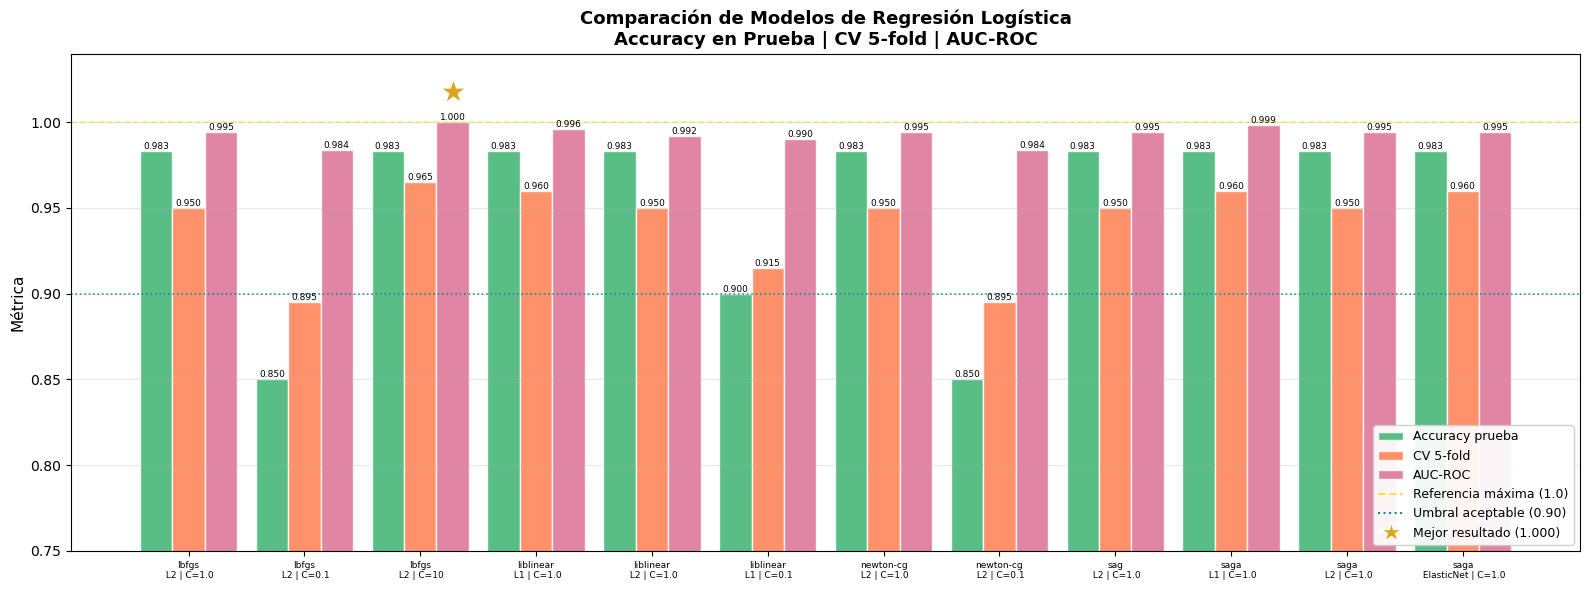

In [75]:
# ============================================================
# Gráfico comparativo de las 3 métricas para cada modelo
# ============================================================
labels_plot = [k.split('|')[0].strip() + '\n' + '|'.join(k.split('|')[1:]) for k in resultados.keys()]
accs = [v['acc'] for v in resultados.values()]
cvs = [v['cv'] for v in resultados.values()]
aucs = [v['auc'] for v in resultados.values()]

x = np.arange(len(labels_plot))
width = 0.28

fig, ax = plt.subplots(figsize=(16, 6))
b1 = ax.bar(x - width, accs, width, label='Accuracy prueba', color='mediumseagreen', alpha=0.85, edgecolor='white')
b2 = ax.bar(x, cvs,  width, label='CV 5-fold', color='coral', alpha=0.85, edgecolor='white')
b3 = ax.bar(x + width, aucs, width, label='AUC-ROC', color='palevioletred', alpha=0.85, edgecolor='white')

# Etiquetas numéricas sobre cada barra
for bar in list(b1) + list(b2) + list(b3):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=6.5)

# Estrella sobre la barra del mejor modelo
# Buscar el valor máximo global entre las 3 métricas
todas_barras = (
    [(b, 'acc') for b in b1] +
    [(b, 'cv')  for b in b2] +
    [(b, 'auc') for b in b3]
)
max_valor = max(b.get_height() for b, _ in todas_barras)

for bar, tipo in todas_barras:
    if bar.get_height() == max_valor:
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # centro de la barra
            bar.get_height() + 0.009,           # encima de la etiqueta
            '★',
            ha='center', va='bottom',
            fontsize=20, color='goldenrod',
            fontweight='bold',
            zorder=5
        )

# Líneas de referencia
ax.axhline(y=1.0, color='gold', linestyle='--', alpha=0.5, lw=1.2)
ax.axhline(y=0.9, color='teal', linestyle=':',  alpha=0.8, lw=1.2)

# Leyenda de barras y líneas
line_100 = Line2D([0], [0], color='gold', linestyle='--',
                  lw=1.5, alpha=0.7,
                  label='Referencia máxima (1.0)')

line_090 = Line2D([0], [0], color='teal', linestyle=':',
                  lw=1.5, alpha=0.9,
                  label='Umbral aceptable (0.90)')

star_patch = Line2D([0], [0],
                    marker='*',
                    color='w',             # línea invisible
                    markerfacecolor='goldenrod',
                    markersize=16,
                    label=f'Mejor resultado ({max_valor:.3f})')

ax.legend(
    handles=[b1, b2, b3, line_100, line_090, star_patch],
    fontsize=9,
    loc='lower right',
    framealpha=0.92
)

ax.set_ylim(0.75, 1.04)
ax.set_xticks(x)
ax.set_xticklabels(labels_plot, fontsize=6.5)
ax.set_ylabel('Métrica', fontsize=11)
ax.set_title('Comparación de Modelos de Regresión Logística\n'
             'Accuracy en Prueba | CV 5-fold | AUC-ROC',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('rl_comparacion_modelos.png', dpi=150)
plt.show()

# Curvas ROC de Todos los Modelos

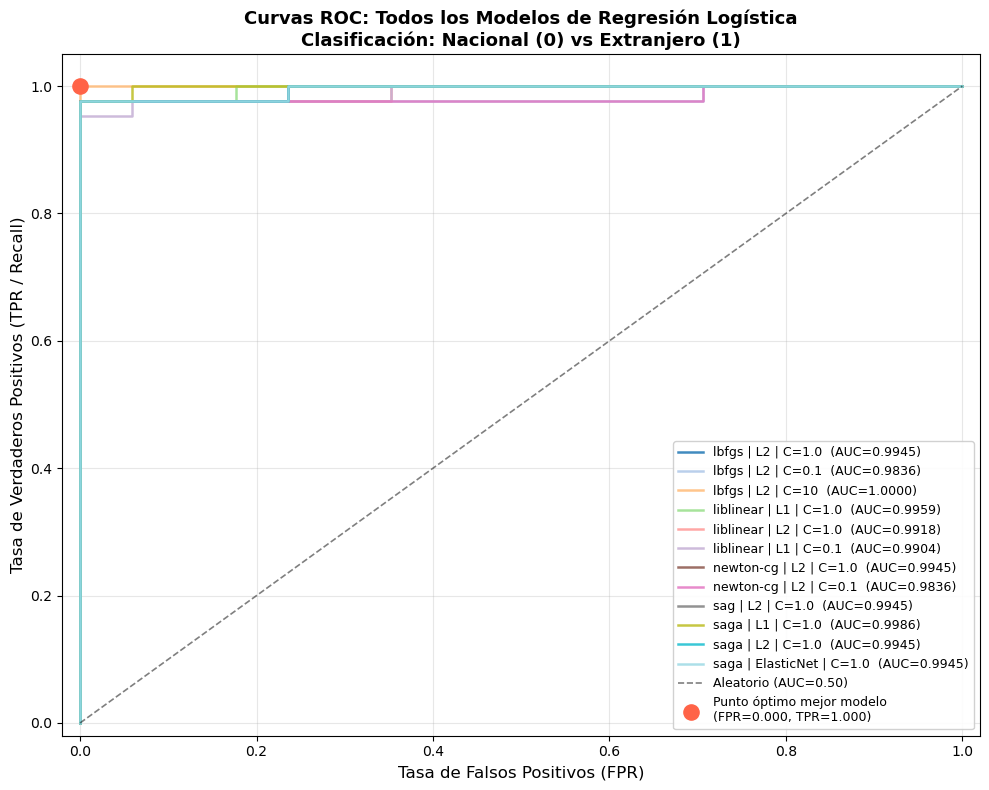

In [77]:
# ============================================================
# Curvas ROC superpuestas
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))

# Paleta de colores para los modelos
colores_roc = plt.cm.tab20(np.linspace(0, 1, len(resultados)))

for (label, res), color in zip(resultados.items(), colores_roc):
    nombre_corto = label.replace('  ', ' ').strip()
    ax.plot(res['fpr'], res['tpr'], lw=1.8, color=color,
            label=f"{nombre_corto}  (AUC={res['auc']:.4f})",
            alpha=0.85)

# Línea de referencia (clasificador aleatorio)
ax.plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.5, label='Aleatorio (AUC=0.50)')

# Punto óptimo del mejor modelo
fpr_best = mejor['fpr']
tpr_best = mejor['tpr']
distancias = np.sqrt(fpr_best**2 + (1 - tpr_best)**2)
idx_opt = np.argmin(distancias)
ax.scatter(fpr_best[idx_opt], tpr_best[idx_opt],
           color='tomato', zorder=5, s=120,
           label=f'Punto óptimo mejor modelo\n'
                 f'(FPR={fpr_best[idx_opt]:.3f}, TPR={tpr_best[idx_opt]:.3f})')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=12)
ax.set_title('Curvas ROC: Todos los Modelos de Regresión Logística\n'
             'Clasificación: Nacional (0) vs Extranjero (1)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
plt.tight_layout()
plt.savefig('rl_curvas_roc.png', dpi=150)
plt.show()

# Curva ROC y Matriz de Confusión del Mejor Modelo

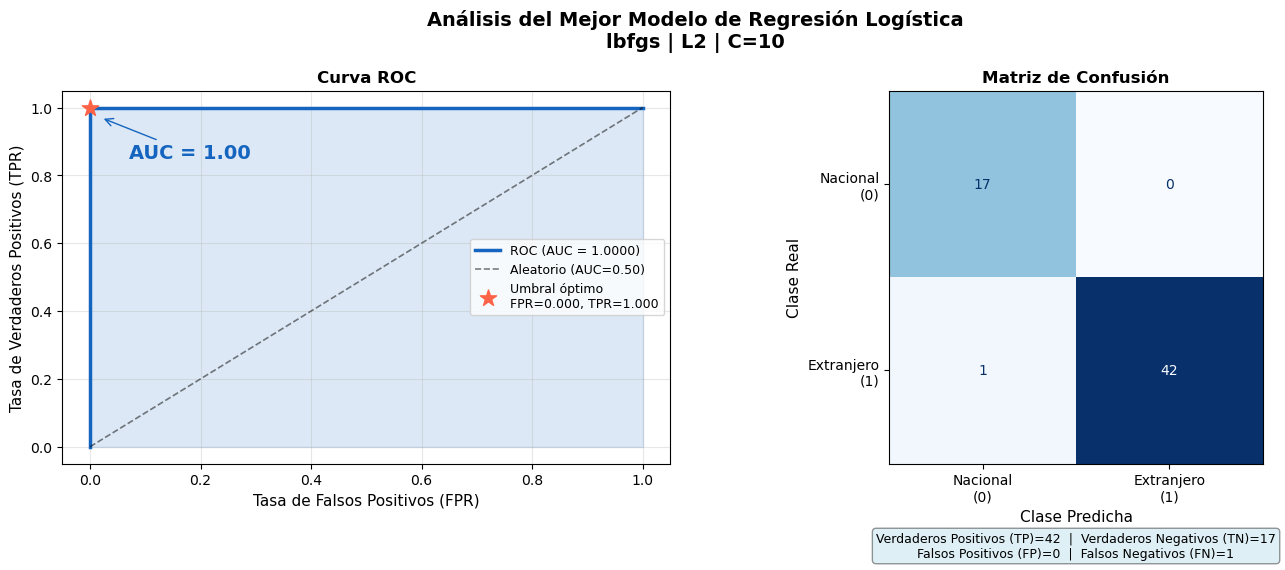

In [96]:
# ============================================================
# Curva ROC detallada del mejor modelo
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel izquierdo: Curva ROC ──
ax = axes[0]
ax.plot(mejor['fpr'], mejor['tpr'], color='#1565C0', lw=2.5,
        label=f'ROC (AUC = {mejor["auc"]:.4f})')
ax.fill_between(mejor['fpr'], mejor['tpr'], alpha=0.15, color='#1565C0')
ax.plot([0,1],[0,1],'k--', lw=1.2, alpha=0.5, label='Aleatorio (AUC=0.50)')

# Punto óptimo
distancias = np.sqrt(mejor['fpr']**2 + (1 - mejor['tpr'])**2)
idx_opt = np.argmin(distancias)
ax.scatter(mejor['fpr'][idx_opt], mejor['tpr'][idx_opt],
           color='tomato', zorder=5, s=150, marker='*',
           label=f"Umbral óptimo\nFPR={mejor['fpr'][idx_opt]:.3f}, "
                 f"TPR={mejor['tpr'][idx_opt]:.3f}")

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title(f'Curva ROC',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Anotación del AUC
ax.annotate(f'AUC = {mejor["auc"]:.2f}',
            xy=(0.02, 0.97), xytext=(0.07, 0.85),
            fontsize=14, fontweight='bold', color='#1565C0',
            arrowprops=dict(arrowstyle='->', color='#1565C0'))

# ── Panel derecho: Matriz de confusión ──
cm = confusion_matrix(y_test, mejor['pred'])
ConfusionMatrixDisplay(cm, display_labels=['Nacional\n(0)', 'Extranjero\n(1)']).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(f'Matriz de Confusión', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Clase Real', fontsize=11)
axes[1].set_xlabel('Clase Predicha', fontsize=11)

# Métricas clave en el gráfico
tn, fp, fn, tp = cm.ravel()
axes[1].text(0.5, -0.25,
    f'Verdaderos Positivos (TP)={tp}  |  '
    f'Verdaderos Negativos (TN)={tn}\n'
    f'Falsos Positivos (FP)={fp}  |  '
    f'Falsos Negativos (FN)={fn}',
    transform=axes[1].transAxes, ha='center', fontsize=9,
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.4))

plt.suptitle(f'Análisis del Mejor Modelo de Regresión Logística\n{mejor_key}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rl_mejor_modelo_roc.png', dpi=150)
plt.show()

# Importancia de Coeficientes

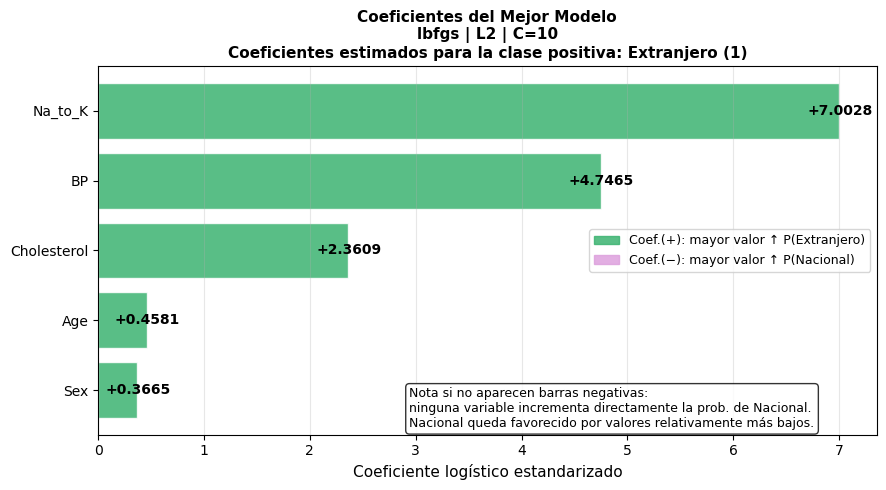

In [120]:
# ============================================================
# Coeficientes del mejor modelo
# ============================================================
coefs = pd.Series(
    mejor['modelo'].coef_[0],
    index=feature_cols
).sort_values(key=abs, ascending=True)

colores_coef = ['mediumseagreen' if v > 0 else 'plum' for v in coefs.values]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(coefs.index, coefs.values,
               color=colores_coef, edgecolor='white', alpha=0.85)

for bar, val in zip(bars, coefs.values):
    xpos = val + 0.05 if val >= 0 else val - 0.05
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos - 0.35, bar.get_y() + bar.get_height()/2,
            f'{val:+.4f}', va='center', ha=ha,
            fontsize=10, fontweight='bold')

ax.axvline(x=0, color='black', lw=1.2, alpha=0.6)

ax.set_xlabel('Coeficiente logístico estandarizado', fontsize=11)
ax.set_title(f'Coeficientes del Mejor Modelo\n{mejor_key}\n'
    'Coeficientes estimados para la clase positiva: Extranjero (1)',
    fontsize=11, fontweight='bold'
)

patch_pos = mpatches.Patch(color='mediumseagreen', alpha=0.85, label='Coef.(+): mayor valor ↑ P(Extranjero)')
patch_neg = mpatches.Patch(color='plum', alpha=0.85, label='Coef.(−): mayor valor ↑ P(Nacional)')
ax.legend(handles=[patch_pos, patch_neg], fontsize=9)

ax.text(0.4, 0.02,
        'Nota si no aparecen barras negativas:\n'
        'ninguna variable incrementa directamente la prob. de Nacional.\n'
        'Nacional queda favorecido por valores relativamente más bajos.',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('rl_coef_mejor_modelo.png', dpi=150)
plt.show()

# Reporte Final del Mejor Modelo

In [116]:
# ============================================================
# Reporte detallado del mejor modelo
# ============================================================
print('=' * 70)
print("REPORTE DETALLADO DEL MEJOR MODELO")
print('=' * 70)
print(f"\n⋆ Configuración : {mejor_key}")
print(f"⋆ Accuracy      : {mejor['acc']:.4f} ({mejor['acc']*100:.2f}%)")
print(f"⋆ CV 5-fold     : {mejor['cv']:.4f} ({mejor['cv']*100:.2f}%)")
print(f"⋆ AUC-ROC       : {mejor['auc']:.4f}")

print("\n⋆ Reporte de Clasificación")
print(classification_report(y_test, mejor['pred'], target_names=['Nacional (0)', 'Extranjero (1)']))

cm = confusion_matrix(y_test, mejor['pred'])
tn, fp, fn, tp = cm.ravel()
print("⋆ Métricas adicionales de la Matriz de Confusión")
print(f"  Verdaderos Positivos (TP) :  {tp}  → Extranjero predicho correctamente")
print(f"  Verdaderos Negativos (TN) :  {tn}  → Nacional predicho correctamente")
print(f"  Falsos Positivos (FP)     :  {fp}   → Nacional mal clasificado como Extranjero")
print(f"  Falsos Negativos (FN)     :  {fn}   → Extranjero mal clasificado como Nacional")
print(f"\n  Especificidad             :  {tn/(tn+fp):.4f}")
print(f"  Sensibilidad (Recall)     :  {tp/(tp+fn):.4f}")
print(f"  Precisión                 :  {tp/(tp+fp):.4f}")

REPORTE DETALLADO DEL MEJOR MODELO

⋆ Configuración : lbfgs | L2 | C=10
⋆ Accuracy      : 0.9833 (98.33%)
⋆ CV 5-fold     : 0.9650 (96.50%)
⋆ AUC-ROC       : 1.0000

⋆ Reporte de Clasificación
                precision    recall  f1-score   support

  Nacional (0)       0.94      1.00      0.97        17
Extranjero (1)       1.00      0.98      0.99        43

      accuracy                           0.98        60
     macro avg       0.97      0.99      0.98        60
  weighted avg       0.98      0.98      0.98        60

⋆ Métricas adicionales de la Matriz de Confusión
  Verdaderos Positivos (TP) :  42  → Extranjero predicho correctamente
  Verdaderos Negativos (TN) :  17  → Nacional predicho correctamente
  Falsos Positivos (FP)     :  0   → Nacional mal clasificado como Extranjero
  Falsos Negativos (FN)     :  1   → Extranjero mal clasificado como Nacional

  Especificidad             :  1.0000
  Sensibilidad (Recall)     :  0.9767
  Precisión                 :  1.0000


# Predicción de Paciente Nuevo (módulo previo)

In [119]:
# ============================================================
# Predicción nuevo paciente (datos de módulo previo)
# Age=50, Sex=F, BP=HIGH, Cholesterol=NORMAL, Na_to_K=15.302
# ============================================================
nuevo = pd.DataFrame({'Age': [50], 'Sex': [0], 'BP': [0],'Cholesterol': [1], 'Na_to_K': [15.302]})
nuevo_sc = scaler.transform(nuevo)

pred_clase = mejor['modelo'].predict(nuevo_sc)[0]
pred_proba = mejor['modelo'].predict_proba(nuevo_sc)[0]
pred_label = etiquetas_proveedor[pred_clase]

print('=' * 60)
print("PREDICCIÓN PARA NUEVA PACIENTE")
print('=' * 60)
print(f"\nAge=50, Sex=F, BP=HIGH, Chol=NORMAL, Na_K=15.302")
print('─' * 55)
print(f"  P(Nacional=0)   : {pred_proba[0]:.4f} ({pred_proba[0]*100:.2f}%)")
print(f"  P(Extranjero=1) : {pred_proba[1]:.4f} ({pred_proba[1]*100:.2f}%)")
print(f"\n  ➤ CLASIFICACIÓN: {pred_clase} — {pred_label}")
print('─' * 55)

PREDICCIÓN PARA NUEVA PACIENTE

Age=50, Sex=F, BP=HIGH, Chol=NORMAL, Na_K=15.302
───────────────────────────────────────────────────────
  P(Nacional=0)   : 0.1762 (17.62%)
  P(Extranjero=1) : 0.8238 (82.38%)

  ➤ CLASIFICACIÓN: 1 — Extranjero (X/Y)
───────────────────────────────────────────────────────


# Análisis y Conclusiones

### Transformación de la variable objetivo
El problema multiclase (5 medicamentos) se reformuló como clasificación **binaria** según el origen del proveedor:
- **Clase 0 → Nacional** : drugA, drugB, drugC  → 55 pacientes (27.5%)
- **Clase 1 → Extranjero**: drugX, drugY        → 145 pacientes (72.5%)

### Comparación de solvers y regularización
Se evaluaron **12 configuraciones** combinando 5 solvers con penalizaciones L1, L2 y Elastic-Net. 

### Mejor modelo: lbfgs | L2 | C=10
Seleccionado por tener el **AUC-ROC perfecto (1.0000)**, Accuracy=0.9833 y CV=0.9650,
siendo además el modelo con mayor suma acumulada de las 3 métricas.

### Matriz de confusión:
- ✔ 17/17 Nacionales clasificados correctamente (0 falsos positivos)
- ✔ 42/43 Extranjeros clasificados correctamente (1 falso negativo)
- ✗ 1 paciente Extranjero clasificado como Nacional

### Curva ROC: AUC=1.0000
El modelo separa perfectamente ambas clases en términos probabilísticos. 
El punto óptimo está en (FPR=0.000, TPR=1.000), el vértice ideal.

### Coeficientes del modelo
Todas las variables tienen coeficiente **positivo**, lo que significa que valores más altos de cada variable aumentan P(Extranjero)
La clase Nacional se predice por bajos valores en estas variables, no por la presencia de factores propios (especialmente Na_to_K bajo).

### Modelo recomendado y eficacia
**Se recomienda `lbfgs | L2 | C=10`** por:
- AUC-ROC = 1.0000 → discriminación perfecta en este conjunto
- Especificidad = 1.0000 → ningún Nacional clasificado como Extranjero
- Recall Nacional = 1.00 → todos los pacientes nacionales identificados
- Solo 1 error total en 60 predicciones

El modelo es **altamente eficaz** para determinar el origen del proveedor del medicamento a prescribir.